In [ ]:
import kagglehub
import os

# Download latest version
base_path = kagglehub.dataset_download("ksir0423/stationery-dataset-1")

# Adjust path to point to the actual data directory
path = os.path.join(base_path, 'Data')

print("Path to dataset files:", path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'stationery-dataset-1' dataset.
Path to dataset files: /kaggle/input/stationery-dataset-1/Data
Contents of base_path (/kaggle/input/stationery-dataset-1):
['Data']
Contents of path (/kaggle/input/stationery-dataset-1/Data):
['Test', 'Train']


In [ ]:
import tensorflow as tf

# Check for GPU availability
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print(f"GPU is available: {gpu_available}")
    print(f"TensorFlow is built with CUDA: {tf.test.is_built_with_cuda()}")
else:
    print("No GPU devices found. Training will run on CPU.")

No GPU devices found. Training will run on CPU.


Now, let's prepare the image dataset and build a ResNet model for training.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Load the dataset from the specified path
# Assuming a typical image classification directory structure (e.g., Data/train/class1, Data/train/class2)
# If your data structure is different, this part might need adjustment.
try:
    train_ds = image_dataset_from_directory(
        path,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE
    )
    val_ds = image_dataset_from_directory(
        path,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE
    )

    # Get class names
    class_names = train_ds.class_names
    num_classes = len(class_names)
    print(f"Found {num_classes} classes: {class_names}")

    # Configure the dataset for performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # Load pre-trained ResNet50 model
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    # Freeze the base model layers
    base_model.trainable = False

    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    # Train the model
    EPOCHS = 10 # You can increase this for better performance
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )
    print("Model training completed.")

except Exception as e:
    print(f"An error occurred during dataset loading or model training: {e}")
    print("Please ensure the 'Data' directory at path: ", path, " has the correct sub-directory structure for image classification (e.g., Data/train/class1, Data/train/class2).")
    print("Or check if the `path` variable (from the previous cell) points to the correct location of your image data.")

Found 1774 files belonging to 2 classes.
Using 1420 files for training.
Found 1774 files belonging to 2 classes.
Using 354 files for validation.
Found 2 classes: ['Test', 'Train']


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,687,938 (97.99 MB)

 Trainable params: 2,100,226 (8.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 321s 7s/step - accuracy: 0.6937 - loss: 1.0650 - val_accuracy: 0.7627 - val_loss: 0.5646
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 276s 6s/step - accuracy: 0.7479 - loss: 0.5546 - val_accuracy: 0.7458 - val_loss: 0.5760
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 285s 6s/step - accuracy: 0.7613 - loss: 0.5337 - val_accuracy: 0.7655 - val_loss: 0.6431
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 279s 6s/step - accuracy: 0.7641 - loss: 0.5239 - val_accuracy: 0.6554 - val_loss: 0.6518
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 328s 6s/step - accuracy: 0.7754 - loss: 0.4891 - val_accuracy: 0.6893 - val_loss: 0.6334
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 279s 6s/step - accuracy: 0.7739 - loss: 0.4834 - val_accuracy: 0.6921 - val_loss: 0.6405
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 284s 6s/step - accuracy: 0.7683 - loss: 0.4954 - val_accuracy: 0.7542 - val_loss: 0.6337
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 306s 7s/step - accuracy: 0.7676 - loss: 0.4837 - val_accuracy: 0.7147 - v

Now, let's summarize the training results.

In [ ]:
if 'history' in locals():
    print("--- Training Results Summary ---")
    final_train_accuracy = history.history['accuracy'][-1]
    final_val_accuracy = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
    print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
    print(f"Final Training Loss: {final_train_loss:.4f}")
    print(f"Final Validation Loss: {final_val_loss:.4f}")
else:
    print("Training history not found. Please ensure the model was trained successfully.")

--- Training Results Summary ---
Final Training Accuracy: 0.7824
Final Validation Accuracy: 0.7345
Final Training Loss: 0.4575
Final Validation Loss: 0.6582


Finally, let's visualize the training progress.

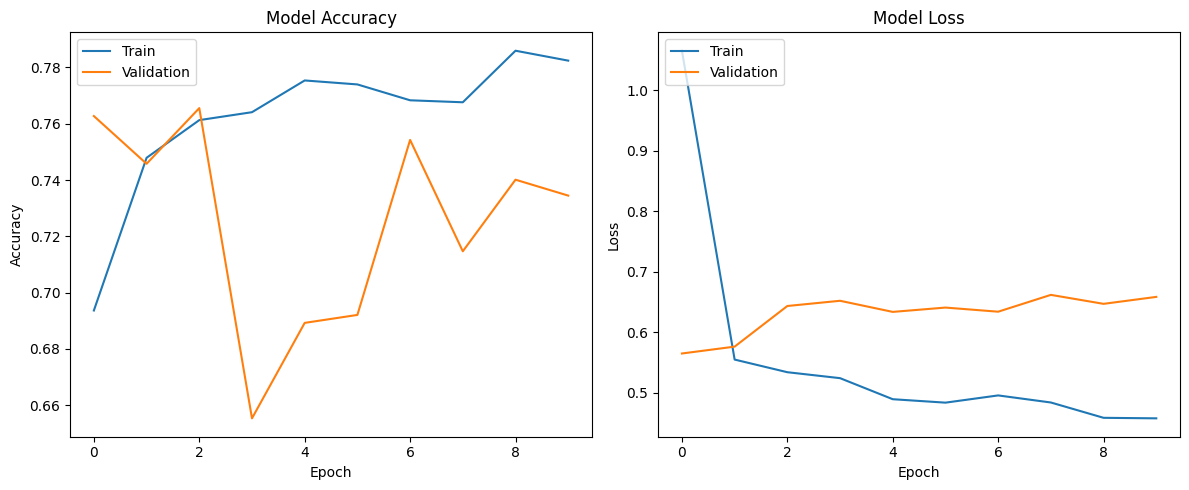

In [ ]:
if 'history' in locals():
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Training history not found. Cannot plot training progress.")